## Week 04 Day 05: The Sidekick

### Importing Required Libraries

In [15]:
# Importing required libraries
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown
from pydantic import BaseModel, Field
from langchain_openai import AzureChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph.state import CompiledStateGraph
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.types import Command
import os
import sys
import json
import importlib

import random
from typing import List, Optional, Annotated
from typing_extensions import TypedDict
from IPython.display import Markdown, display, Image
import gradio as gr
import urllib3
import requests
import re
import asyncio
import datetime
import win32com.client
import pythoncom
import subprocess
import time

from sidekick_tools import search_serpapi_tool, send_email_tool
from web_tools import WIKIPEDIA_TOOLS, wikipedia_search, wikipedia_get_page, BROWSER_TOOLS, ALL_TOOLS
import sidekick
importlib.reload(sidekick)
from sidekick import Sidekick

load_dotenv(override = True)

True

### Load .env variables

In [2]:
# Let's see if the API key is working/helping us to call LLM from Azure Foundry
import os
# From OpenAI
AZURE_OPENAI_API_KEY= os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_MODEL_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT")
AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION")
AZURE_OPENAI_DEPLOYMENT_GPT_41 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_41")
AZURE_OPENAI_DEPLOYMENT_GPT_54_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_54_mini")
AZURE_OPENAI_DEPLOYMENT_GPT_55 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_55")
AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini")
if AZURE_OPENAI_API_KEY:
    print("AZURE_OPENAI_API_KEY is available")
else:
    print("AZURE_OPENAI_API_KEY is not available")

# From Anthropic
AZURE_CLAUDE_DEPLOYMENT_OPUS_48=os.getenv("AZURE_CLAUDE_DEPLOYMENT_OPUS_48")
AZURE_CLAUDE_ENDPOINT=os.getenv("AZURE_CLAUDE_ENDPOINT")
AZURE_CLAUDE_API_KEY=os.getenv("AZURE_CLAUDE_API_KEY")
if AZURE_CLAUDE_API_KEY:
    print("AZURE_CLAUDE_API_KEY is avaiable")
else:
    print("AZURE_CLAUDE_API_KEY is not available")

# setting up tavily api key
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
SERP_API_KEY=os.getenv("SERP_API_KEY")
if SERP_API_KEY:
    print("SERP Available")
else:
    print("SERP Not Available")

EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS_TO")
if EMAIL_ADDRESS:
    print("Email address present!")
else:
    print("Email adderess not found!")

AZURE_OPENAI_API_KEY is available
AZURE_CLAUDE_API_KEY is avaiable
SERP Available
Email address present!


### Making Model Ready

In [3]:
## Setting up the llm from Azure Foundry
llm = AzureChatOpenAI(
    api_key = AZURE_OPENAI_API_KEY,
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    azure_deployment = AZURE_OPENAI_DEPLOYMENT_GPT_54_mini,
    api_version = AZURE_OPENAI_API_VERSION
)

### Make some handy functions/methods to call later

In [4]:
# making a function to make ready a user prompt with acutal prompt
def user_prompt(prompt: str) -> dict:
    message = {
        "messages":[
            {
                "role": "user",
                "content": prompt
            }
        ]
    }
    return message
user_prompt("What is my name")

# make a function to print the results of agent call in Markdown format
def print_markdown(result: dict) -> str:
    print("Agent's answer is as follows: \n")
    return display(Markdown(result['messages'][-1].content))

## Let's make a function of visualizing agent's structure
def draw_structure(agent: CompiledStateGraph) -> bytes:
    return display(Image(agent.get_graph().draw_png()))


# let's make a method to listdown the tool calls done by agent
def show_toolcalls(result: dict) -> list:
    tools_used = [toolcall['name'] for message in result['messages'] for toolcall in (getattr(message,"tool_calls", []) or [])]
    print("\nTools the agent called, in order: ")
    return tools_used

### One Adjustment for Windows

In [5]:
## A small coding patch to run for Windows as to handle programs error log location
import sys
if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the windows adjustment")
else:
    print("Not Windows, so nothing to do here!")


Applied the windows adjustment


### Step 01: The simplest Sidekick, with no evaluator

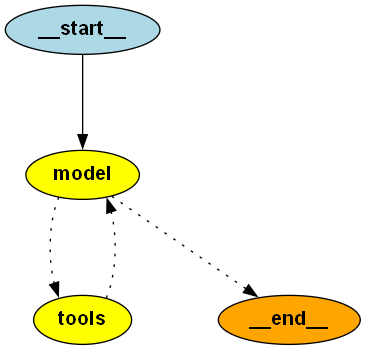

In [6]:
simple_worker = create_agent(
    model = llm,
    tools = [search_serpapi_tool, send_email_tool,  wikipedia_search, wikipedia_get_page],
    system_prompt = "You're 'The SideKick', a helpful personal assistant. Use your tools to complete the task.",
    checkpointer=InMemorySaver()
    )

draw_structure(simple_worker)

In [7]:
async def ask(worker, message):
    config = {
        "configurable": {
            "thread_id": "simple-sidekick"
        }
    }
    result = await worker.ainvoke(user_prompt(message), config=config)
    return print_markdown(result), show_toolcalls(result)

reply, toolcalls = await ask(simple_worker, "Search for who won the Nobel Prize in Physics/Mathematics in last 2-3 years and send an email with a short summary.")
print(reply, "\n" , toolcalls)



******************* SERP-API-TOOL-CALLED ************************


******************* SERP-API-TOOL-CALLED ************************


Searching Wikipedia for query: Nobel Prize in Physics 2024 2023 winners


Searching Wikipedia for query: Mathematics prize last 2-3 years winners Nobel related

[DEBUG] HTTP Status Code: 200
[DEBUG] Content-Type Header: application/json; charset=utf-8

 ###########-printing SERP api response-############
1. All Nobel Prizes
   URL: https://www.nobelprize.org/prizes/lists/all-nobel-prizes/
   With some receiving the Nobel Prize more than once, this makes a total of 990 individuals and 28 organisations. Below, you can view the full list of Nobel ...

2. Abel Prize
   URL: https://en.wikipedia.org/wiki/Abel_Prize
   The Abel Prize is awarded annually by the King of Norway to one or more outstanding mathematicians. It is named after the Norwegian mathematician Niels ...

3. Prizes, Awards, and Honors for Women Mathematicians
   URL: https://mathwomen.agne

Done — I searched the recent winners and sent an email with a short summary.

Key note: there is no Nobel Prize in Mathematics, so I used the Abel Prize as the math equivalent.


Tools the agent called, in order: 
None 
 ['search_serpapi_tool', 'search_serpapi_tool', 'wikipedia_search', 'wikipedia_search', 'search_serpapi_tool', 'send_email_tool']


### Step 2: human-in-the-loop with middleware

In [ ]:
@tool
def book_meeting(person: str, day: str) -> str:
    """Book a meeting with a person on a given day. """
    return f"Meeting booked with {person} on {day}"

approval_agent = create_agent(
    model = llm,
    tools = [book_meeting],
    system_prompt = "You're a scheduling assistant. Use the book_meeting tool.",
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"book_meeting": True})],
    checkpointer = InMemorySaver(),
)

config = {
    "configurable": { 
        "thread_id": "approval-agent"
    }
}
result = await approval_agent.ainvoke(user_prompt("Book a meeting with Sam on upcoming Monday"),config=config)
print_markdown(result)
interrupt = result["__interrupt__"][0]
print("The agent paused and is asking for approval:\n")
print(interrupt.value['action_requests'][0]['description'])

Agent's answer is as follows: 



The agent paused and is asking for approval:

Tool execution requires approval

Tool: book_meeting
Args: {'person': 'Sam', 'day': 'upcoming Monday'}


In [8]:
## Let's call above agent again saying that it's been approved by human
resumed = await approval_agent.ainvoke(Command(resume={'decisions':[{"type": "approve"}]}), config)
print_markdown(resumed)

Agent's answer is as follows: 



Meeting booked with Sam on upcoming Monday.

#### We can choose how to respond
{"type":"approve"} instead of this, we can 
- {"type": "edit", "edited_action": {"name": "book_meeting", "args": {"person":"Sam", "day": "Tuesday"}}}
- {"type": "reject", "message": "No meetings on Fridays"}

In [12]:
## Let's try it out
config = {
    "configurable": {
        "thread_id": "rejection-demo-01"
    }
}
result = await approval_agent.ainvoke(user_prompt("Book a meeting with Hardeep on Saturday"),config)
interrupt = result['__interrupt__'][0]
print("The agent paused and is asking for approval:\n")
print(interrupt.value['action_requests'][0]['description'])

The agent paused and is asking for approval:

Tool execution requires approval

Tool: book_meeting
Args: {'person': 'Hardeep', 'day': 'Saturday'}


In [15]:
resumed = await approval_agent.ainvoke(Command(
    resume={
        "decisions":[
            {
                "type": "reject",
                "message": "No meetings on Saturday, it's weekend!"
            }
        ]
    }
    ), config=config
)
print_markdown(resumed)

Agent's answer is as follows: 



I can’t book meetings on Saturday because it’s the weekend. If you want, I can book it for a weekday instead.

### Step 03: The Full Sidekick

In [17]:
sidekick = Sidekick()
await sidekick.setup()
print(f"Sidekick ready with {len(sidekick.tools)} tools.")

Sidekick ready with 32 tools.


In [7]:
# checking the tools this agent is provided
sidekick.tools

[StructuredTool(name='request_human_help', description='Ask the user to do something in the browser window that you cannot do yourself,\n    such as logging in to a site, passing a captcha, or approving two-factor authentication.\n    Explain exactly what you need them to do. The run pauses until they have done it.', args_schema=<class 'langchain_core.utils.pydantic.request_human_help'>, func=<function request_human_help at 0x0000015BE5517380>),
 StructuredTool(name='search_serpapi_tool', description='Performs a search using SerpApi and prints raw response metadata if JSON parsing fails.\n    Then print and return readable search results from a SerpApi response.', args_schema=<class 'langchain_core.utils.pydantic.search_serpapi_tool'>, func=<function search_serpapi_tool at 0x0000015BE41AF880>),
 StructuredTool(name='send_email_tool', description='Send an email using the local Outlook desktop client.', args_schema=<class 'langchain_core.utils.pydantic.send_email_tool'>, func=<function s

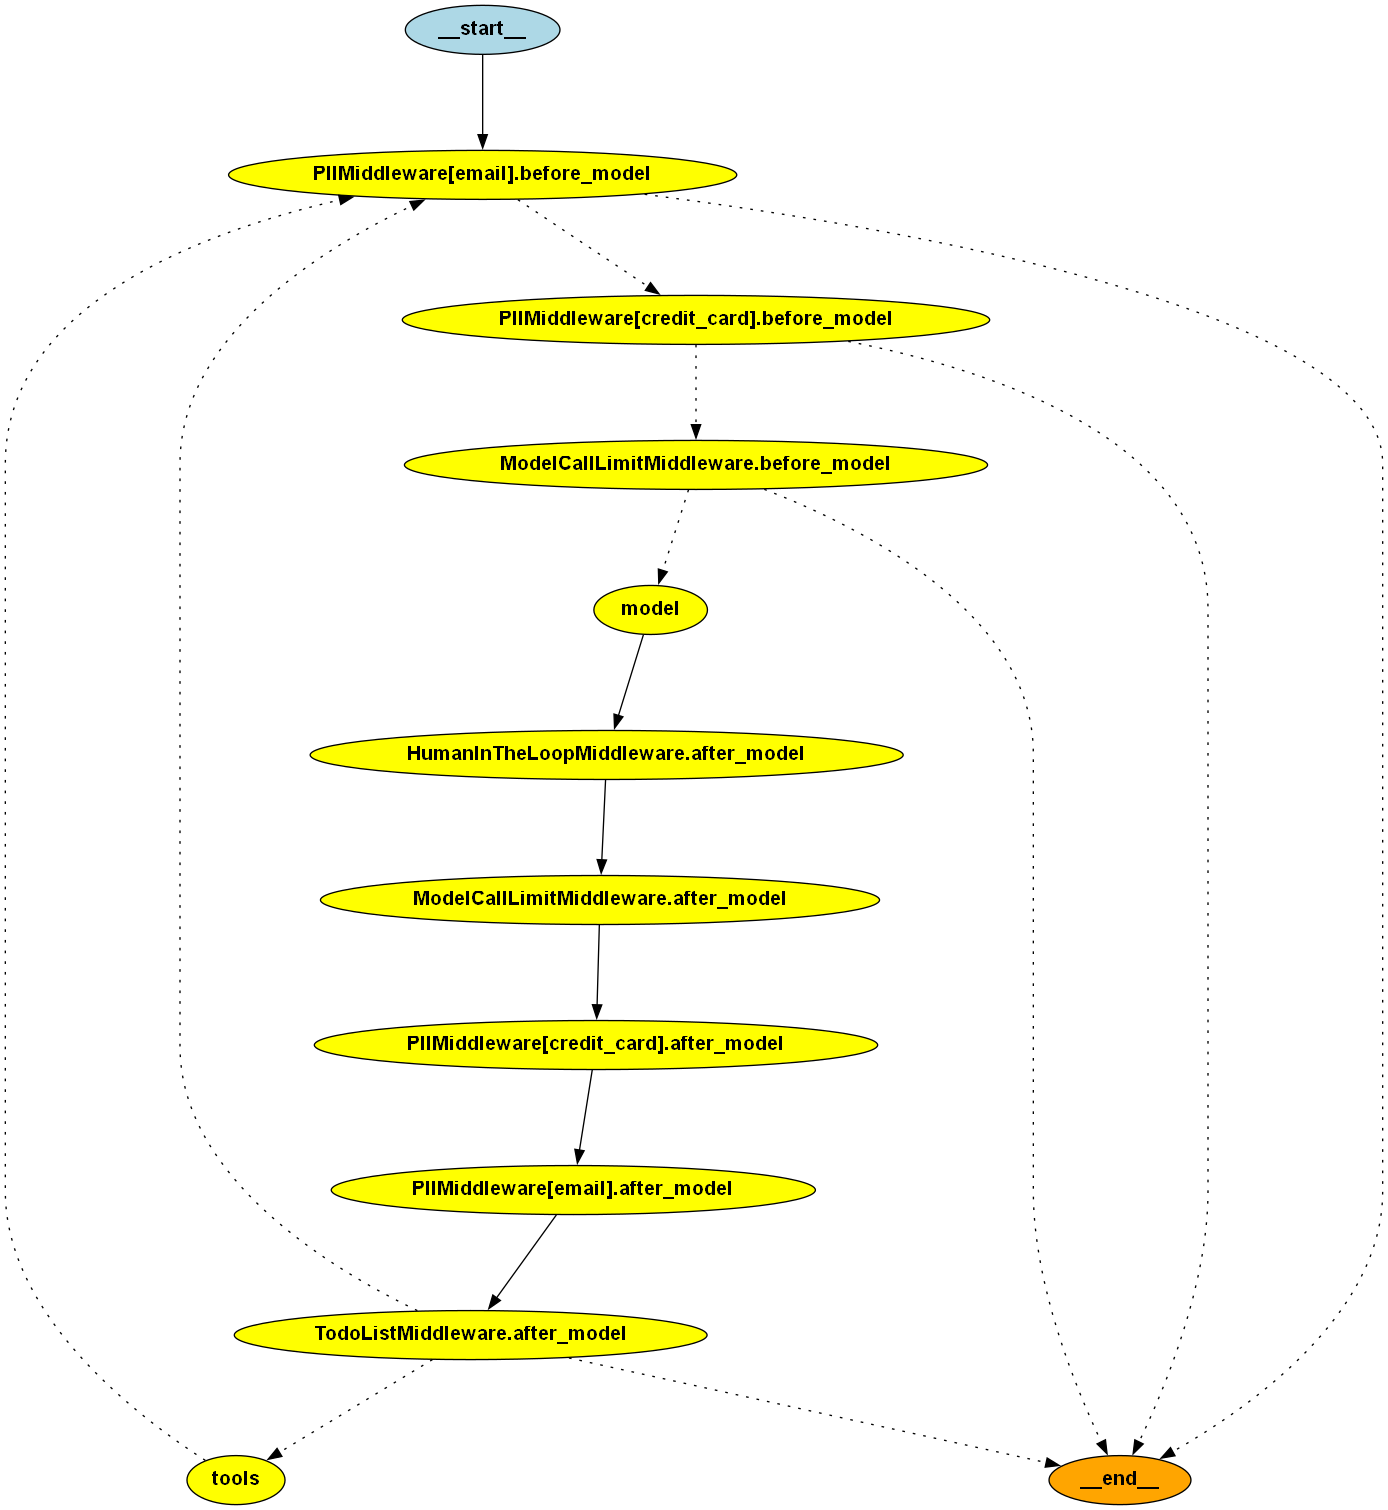

In [8]:
## let's see the structure or diagram of this agent
draw_structure(sidekick.worker)

In [13]:
# let's call it 
history = await sidekick.run_turn(
    message = "Go to Hacker News at news.ycombinator.com and tell me the title of the current top story.",
    success_criteria = "The reply names a specific story currently on the hacker News front page.",
    history = [],
)
for entry in history:
    print(f"[{entry['role']}] {entry['content'][:200]}\n")
    

[user] Go to Hacker News at news.ycombinator.com and tell me the title of the current top story.

[assistant] The current top story on Hacker News is **“Vectorized and performance-portable Quicksort”**.

[assistant] Evaluator: The assistant named a specific Hacker News front-page story: “Vectorized and performance-portable Quicksort.” This satisfies the success criteria.



### The final: A real job

In [18]:
flight_task = """Find me the best round-trip flight from Bangalore to Chandigarh, leaving about a month from now
and returning a week later. I care about price first, then total journey time, and I would rather avoid
itineraries with one or more stops. Write your recommendation with the top three options to flights.md,
then send me an email with the price of your top pick."""

flight_criteria = "flights.md is written with three specific options including airline, times and price, plus a clear recommendation, and an email was sent with the recommended price."

history = await sidekick.run_turn(flight_task, flight_criteria, history)
print(history[-1]["content"])

Waiting for your approval: 
Tool execution requires approval

Tool: send_email_tool
Args: {'subject': 'Top Bangalore to Chandigarh flight price', 'body': 'Top pick: IndiGo round-trip Bangalore to Chandigarh for ₹19,543.\n\nDeparture: 17 Oct 2026, Bengaluru 2:50 PM → Chandigarh 10:15 PM.\nThis was the cheapest option found, so I recommend it based on your pricing priority.'}


In [20]:
for todo in sidekick.todos:
    print(f"[{todo['status']}] {todo['content']}")

[completed] Search round-trip Bangalore → Chandigarh flights for ~1 month from now and return a week later
[in_progress] Compare options by price, then journey time, preferring nonstop flights
[pending] Write top three options and recommendation to flights.md
[pending] Email the price of the top pick to the user


In [21]:
if sidekick.paused:
    history = await sidekick.resume(history)

for entry in history:
    print(f"[{entry['role']}] {entry['content']}\n")


Sending email to hardeep.singh3@lseg.com with subject 'Top Bangalore to Chandigarh flight price'...
Outlook is up & running...

Email sent successfully to 'hardeep.singh3@lseg.com' with subject 'Top Bangalore to Chandigarh flight price'.
[user] Go to Hacker News at news.ycombinator.com and tell me the title of the current top story.

[assistant] The current top story on Hacker News is **“Vectorized and performance-portable Quicksort”**.

[assistant] Evaluator: The assistant named a specific Hacker News front-page story: “Vectorized and performance-portable Quicksort.” This satisfies the success criteria.

[user] Find me the best round-trip flight from Bangalore to Chandigarh, leaving about a month from now
and returning a week later. I care about price first, then total journey time, and I would rather avoid
itineraries with one or more stops. Write your recommendation with the top three options to flights.md,
then send me an email with the price of your top pick.

[assistant] Waiting